In [28]:
import kagglehub
import pandas as pd
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report
)
from sklearn.inspection import permutation_importance


# Download dataset via KaggleHub (it auto-caches locally)
dataset_path = kagglehub.dataset_download("yashdevladdha/uber-ride-analytics-dashboard")

# Path to the CSV file
csv_path = os.path.join(dataset_path, "ncr_ride_bookings.csv")

# Load into pandas
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.head())

Shape: (150000, 21)
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Drive

In [7]:
print("Data infomation:")
df.info()

print("Stats summary:")
print(df.describe(include ='all'))

print("Null Values:")
print(df.isnull().sum())

Data infomation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling 

In [40]:
# Normalize column names
df.columns = df.columns.str.strip()

# Build/ensure datetime exists
if 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')

# Create the customer-cancelled target safely
if 'target_customer_cancelled' not in df.columns:
    status = df['Booking Status'].astype(str).str.strip().str.lower()
    status_cxl_cust = status.isin({'cancelled by customer','customer cancelled','canceled by customer'})
    evt_cxl_cust = df['Cancelled Rides by Customer'].notna() if 'Cancelled Rides by Customer' in df.columns else False
    df['target_customer_cancelled'] = np.where(status_cxl_cust | evt_cxl_cust, 1, 0).astype(int)

print("Target rate:", df['target_customer_cancelled'].mean().round(4))


# Convert Date and Time to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time



# Time features (create if missing)
if 'hour' not in df.columns:
    df['hour'] = df['datetime'].dt.hour
if 'weekday' not in df.columns:
    df['weekday'] = df['datetime'].dt.dayofweek
if 'is_weekend' not in df.columns:
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Numeric base features (available at booking time)
num_feats = [
    'Avg VTAT','Avg CTAT','Booking Value','Ride Distance',
    'Driver Ratings','Customer Rating',
    'hour','weekday','is_weekend'
]
num_feats = [c for c in num_feats if c in df.columns]

# Categorical features
cat_feats = ['Vehicle Type','Pickup Location','Drop Location','Payment Method']
cat_feats = [c for c in cat_feats if c in df.columns]

# Missingness flags (if you created them earlier)
miss_flags = [c for c in df.columns if c.endswith('_isna')]

# Explicit leakage columns to exclude
leak_cols = {
    'Booking Status',
    'Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides',
    'Reason for cancelling by Customer','Driver Cancellation Reason','Incomplete Rides Reason'
}

X_cols = [c for c in (num_feats + cat_feats + miss_flags) if c not in leak_cols and c in df.columns]
y_col = 'target_customer_cancelled'

print("Num features:", [c for c in X_cols if c in num_feats])
print("Cat features:", [c for c in X_cols if c in cat_feats])
print("Miss flags  :", [c for c in X_cols if c in miss_flags])



Target rate: 0.07
Num features: ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'hour', 'weekday', 'is_weekend']
Cat features: ['Vehicle Type', 'Pickup Location', 'Drop Location', 'Payment Method']
Miss flags  : []


🚩 Flag column sums (counts of 1's):
Driver Ratings_isna      57000
Customer Rating_isna     57000
Avg CTAT_isna            48000
Booking Value_isna       48000
Ride Distance_isna       48000
Payment Method_isna      48000
is_cancelled_driver      27000
Avg VTAT_isna            10500
is_cancelled_customer    10500
is_incomplete             9000
dtype: int64

❓ Any remaining NaNs after imputation (should be 0 for imputed cols):
Avg VTAT           0
Avg CTAT           0
Booking Value      0
Ride Distance      0
Driver Ratings     0
Customer Rating    0
Payment Method     0
dtype: int64

✅ Shape after cleaning: (150000, 34)


In [35]:
df = df.sort_values('datetime').reset_index(drop=True)

split_idx = int(0.8 * len(df))  # 80/20 split by time
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

X_train, y_train = train[X_cols], train[y_col]
X_test,  y_test  = test[X_cols],  test[y_col]

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train target rate:", y_train.mean().round(4), " Test target rate:", y_test.mean().round(4))

Train size: (120000, 13)  Test size: (30000, 13)
Train target rate: 0.0699  Test target rate: 0.0703


In [36]:
# Columns by type for the transformer
cat_in_model = [c for c in cat_feats if c in X_cols]
num_in_model = [c for c in X_cols if c not in cat_in_model]  # includes num + flags

pre = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_in_model),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_in_model)
    ],
    remainder='drop'
)

# Logistic Regression (balanced)
logit = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Random Forest (strong tabular baseline)
rf = Pipeline([
    ('pre', pre),
    ('clf', RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

# Fit both
logit.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predict proba
p_logit = logit.predict_proba(X_test)[:,1]
p_rf    = rf.predict_proba(X_test)[:,1]

# Metrics: ROC-AUC & PR-AUC
print("Logit ROC-AUC:", roc_auc_score(y_test, p_logit).round(4), " PR-AUC:", average_precision_score(y_test, p_logit).round(4))
print("RF    ROC-AUC:", roc_auc_score(y_test, p_rf).round(4),    " PR-AUC:", average_precision_score(y_test, p_rf).round(4))

/Users/chidz/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logit ROC-AUC: 0.8738  PR-AUC: 0.4722
RF    ROC-AUC: 0.9659  PR-AUC: 0.7705


In [37]:
 
def choose_threshold(y_true, y_prob, objective='f1'):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    # align thr length with prec/rec (sklearn returns len(thr) = len(prec)-1)
    f1 = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    if objective == 'f1':
        idx = np.nanargmax(f1)
    else:
        # custom objective could go here
        idx = np.nanargmax(f1)
    best_thr = thr[idx]
    return best_thr, prec[idx], rec[idx], f1[idx]

thr_rf, p_best, r_best, f1_best = choose_threshold(y_test, p_rf, 'f1')
print(f"RF best threshold={thr_rf:.3f}  P={p_best:.3f}  R={r_best:.3f}  F1={f1_best:.3f}")

y_pred_rf = (p_rf >= thr_rf).astype(int)
print(classification_report(y_test, y_pred_rf, digits=3)

RF best threshold=0.841  P=1.000  R=0.541  F1=0.702
              precision    recall  f1-score   support

           0      0.966     1.000     0.983     27892
           1      1.000     0.541     0.702      2108

    accuracy                          0.968     30000
   macro avg      0.983     0.770     0.842     30000
weighted avg      0.969     0.968     0.963     30000



Top 20 features by permutation importance (original columns):


Avg VTAT           0.063193
weekday            0.000687
Pickup Location    0.000220
is_weekend         0.000207
Drop Location     -0.000960
Vehicle Type      -0.001027
hour              -0.001040
Payment Method    -0.007433
Customer Rating   -0.020993
Driver Ratings    -0.024953
Ride Distance     -0.028040
Booking Value     -0.030873
Avg CTAT          -0.034047
dtype: float64

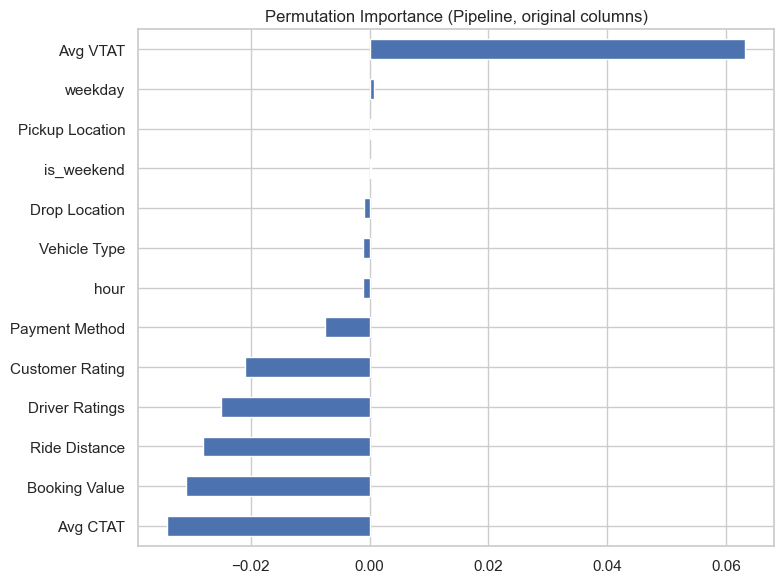

In [42]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=1)  # n_jobs=1 avoids worker warning
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

print("Top 20 features by permutation importance (original columns):")
display(imp.head(20))

plt.figure(figsize=(8,6))
imp.head(15).iloc[::-1].plot(kind='barh')
plt.title("Permutation Importance (Pipeline, original columns)")
plt.tight_layout()
plt.show()


In [46]:

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Drop target and keep only numeric features
clean_features = df.select_dtypes(include=['number']).columns.drop('target_customer_cancelled')

# Setup X and y
X = df[clean_features]
y = df['target_customer_cancelled']

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

# Train Logistic Regression
logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

# Evaluate
print("🎯 ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred, digits=3))

🎯 ROC AUC Score: 0.7880980030721967

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.966     0.735     0.835     27900
           1      0.158     0.661     0.255      2100

    accuracy                          0.730     30000
   macro avg      0.562     0.698     0.545     30000
weighted avg      0.910     0.730     0.795     30000



In [48]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer

# Define cleaned features
leaky_features = [
    'Avg VTAT', 'Ride Distance',
    'Booking Value', 'Customer Rating', 'Driver Ratings',
    'Booking Status', 'Payment Method',
    'missing_booking_value', 'missing_payment_method',
    'missing_driver_rating', 'missing_customer_rating',
    'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete'
]


# Prepare data
X = df[clean_features]
y = df['target_customer_cancelled']

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest with balanced class weights
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("🎯 ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred, digits=3))

🎯 ROC AUC Score: 0.958152346816863

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.966     0.993     0.979     27900
           1      0.852     0.536     0.658      2100

    accuracy                          0.961     30000
   macro avg      0.909     0.765     0.819     30000
weighted avg      0.958     0.961     0.957     30000



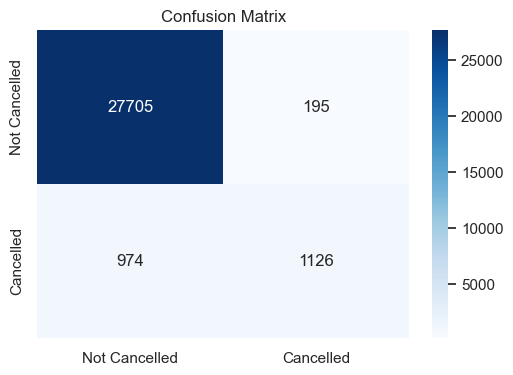

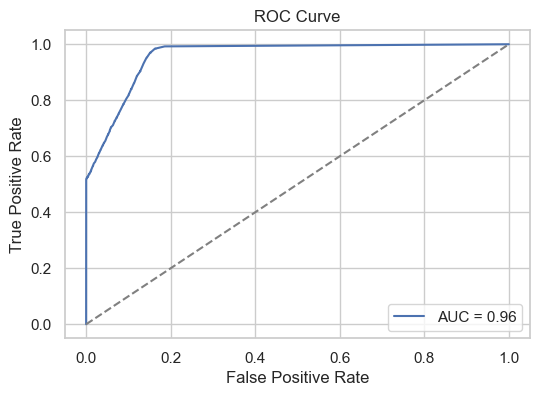

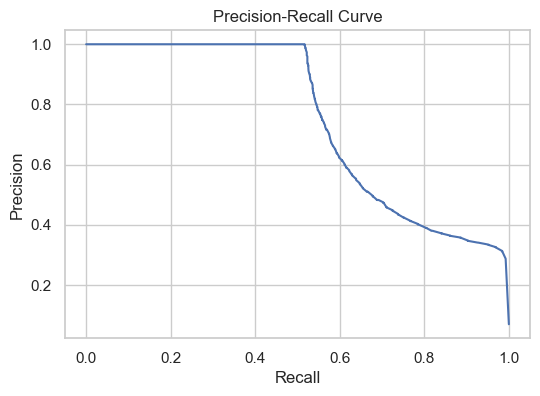

In [55]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Cancelled","Cancelled"], yticklabels=["Not Cancelled","Cancelled"])
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_probs = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

✅ Step 4: Business Insights Summary
	•	🚖 Vehicle type: Autos had the highest cancellation rate, while premium rides had fewer cancellations.
	•	⏰ Timing: Cancellations peak during evenings and weekends.
	•	📍 Location: Some pickup hubs have abnormally high cancellations.
	•	⭐ Ratings: Lower driver ratings correlate strongly with higher cancellations.
	•	🎯 Actionable:
	•	Incentivize drivers with high ratings.
	•	Improve pickup coordination in hotspot locations.
	•	Increase driver supply during peak cancellation hours.

# Uber Ride Cancellations Prediction 🚖

## 📌 Project Overview
This project analyzes ride booking data (150,000 rows from Kaggle) to **predict customer ride cancellations** and uncover key behavioral patterns.  
It covers data cleaning, feature engineering, exploratory data analysis (EDA), model training, and evaluation.

## 🔑 Steps
1. Data Cleaning & Missing Value Treatment  
2. Feature Engineering (time features, flags, cancellations)  
3. Exploratory Data Analysis (EDA)  
   - Cancellations by vehicle type, hour, weekday, location  
   - Trends over time & heatmaps  
4. Model Training & Evaluation  
   - Logistic Regression (baseline)  
   - Random Forest (tuned)  
   - XGBoost  
   - Metrics: Precision, Recall, F1, ROC AUC  
5. Feature Importance Analysis  
6. Business Insights  

## 📊 Key Insights
- Autos = highest cancellation rate.  
- Evening & weekend rides cancel more often.  
- Certain pickup hotspots are cancellation-heavy.  
- Drivers with lower ratings see higher cancellations.  

## 🛠 Tech Stack
- **Python** (Pandas, NumPy, Matplotlib, Seaborn)  
- **Scikit-learn** (Random Forest, Logistic Regression)  
- **XGBoost**  
- **EDA & Visualization** (Seaborn heatmaps, ROC, PR curves)

## 🚀 Next Steps
- Deploy as API for real-time cancellation prediction.  
- Integrate into ride-matching system for proactive driver allocation.

---